<a href="https://colab.research.google.com/github/nepslor/teaching/blob/main/TimeSeriesForecasting/W9/foundation_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundational models
One of the most influential developments in deep learning has been the transformer architecture, introduced in Attention Is All You Need (Vaswani et al. 2017). Unlike traditional recurrent neural networks (RNNs) or long short-term memory (LSTM) networks, transformers process entire input sequences in parallel rather than sequentially. This eliminates the need for step-by-step recurrence, making them more scalable and efficient for large datasets.

In this exercise we will run two fundational models for:
* transfer learning
* predicting with covariates



In [1]:
%%capture
!pip install --upgrade pip setuptools wheel
!pip install numpy==1.26.4 pandas==2.1.4
!pip install matplotlib ipython python-dotenv
!pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cpu
!pip install nixtla
!pip install fpppy uni2ts
!pip install gluonts==0.14.4

❗ Due to incompatibility issues, you must restart the session now! `Runtime --> Restart Session`


In [ ]:
%%capture
!pip install datasetsforecast neuralforecast

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
from nixtla import NixtlaClient
from dotenv import load_dotenv
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae
from datasetsforecast.m4 import M4
from neuralforecast.core import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.utils import AirPassengersDF
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

plt.style.use("ggplot")
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])

os.environ["NIXTLA_ID_AS_COL"] = "true"
pd.set_option("display.precision", 3)

from fpppy.utils import plot_series

# Transfer learinig
Transfer-learning refers to pre-training a model on a (usually large) source dataset to improve its performance on a new forecasting task with a target dataset.

The core idea of a foundation models is to leverage this principle by training it on large time series dataset, leveraging scaling laws on the dataset and model sizes. A diverse dataset, in terms of breadth and depth is necessary for the model to perform in a wide variety of domains.


In the following simple example we illustrate this process by pre-training the NHITS (Challu et al. 2023) on the M4 monthly dataset. The M4 dataset is a collection of 100,000 time series

Key techniques implemented in NHiTS (Neural Hierarchical Interpolation for Time Series Forecasting)

* Multi-Rate Data Sampling
* Neural Basis Expansion Analysis
* Doubly Residual Stacking
* Hierarchical Interpolation

<img src="https://substackcdn.com/image/fetch/f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fd520fbc5-2ad3-4751-88e4-67280423de22_700x454.png" width="500"/>



In [3]:
Y_df, _, _ = M4.load(directory="./", group="Monthly")
Y_df["ds"] = Y_df.groupby("unique_id")["ds"].transform(
    lambda x: pd.date_range(start="1970-01-01", periods=len(x), freq="MS")
)
Y_df.head()

91.7MiB [00:01, 47.1MiB/s]
ERROR:datasetsforecast.utils:ERROR, something went wrong downloading data
7.94MiB [00:00, 48.5MiB/s]
ERROR:datasetsforecast.utils:ERROR, something went wrong downloading data
4.34MiB [00:00, 66.7MiB/s]                 
ERROR:datasetsforecast.utils:ERROR, something went wrong downloading data
100%|██████████| 3.56M/3.56M [00:00<00:00, 30.4MiB/s]


,unique_id,ds,y
0,M1,1970-01-01,8000.0
1,M1,1970-02-01,8350.0
2,M1,1970-03-01,8570.0
3,M1,1970-04-01,7700.0
4,M1,1970-05-01,7080.0


### Fitting on M4

In [4]:
horizon = 12
stacks = 3
models = [
    NHITS(
        input_size=5 * horizon,
        h=horizon,
        max_steps=2_000,
        stack_types=stacks * ["identity"],
        n_blocks=stacks * [1],
        mlp_units=[[256, 256] for _ in range(stacks)],
        n_pool_kernel_size=stacks * [1],
        batch_size=32,
        scaler_type="standard",
        n_freq_downsample=[12, 4, 1],
    )
]

nf = NeuralForecast(models=models, freq="M")
nf.fit(df=Y_df)


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 689 K  | train
-------------------------------------------------------
689 K     Trainable params
0         Non-trainable params
689 K     Total params
2.757     Total estimated model params size (MB)
34        Modules in train mode
0       

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_steps=2000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=2000` reached.


### Predicting AirPassengers

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

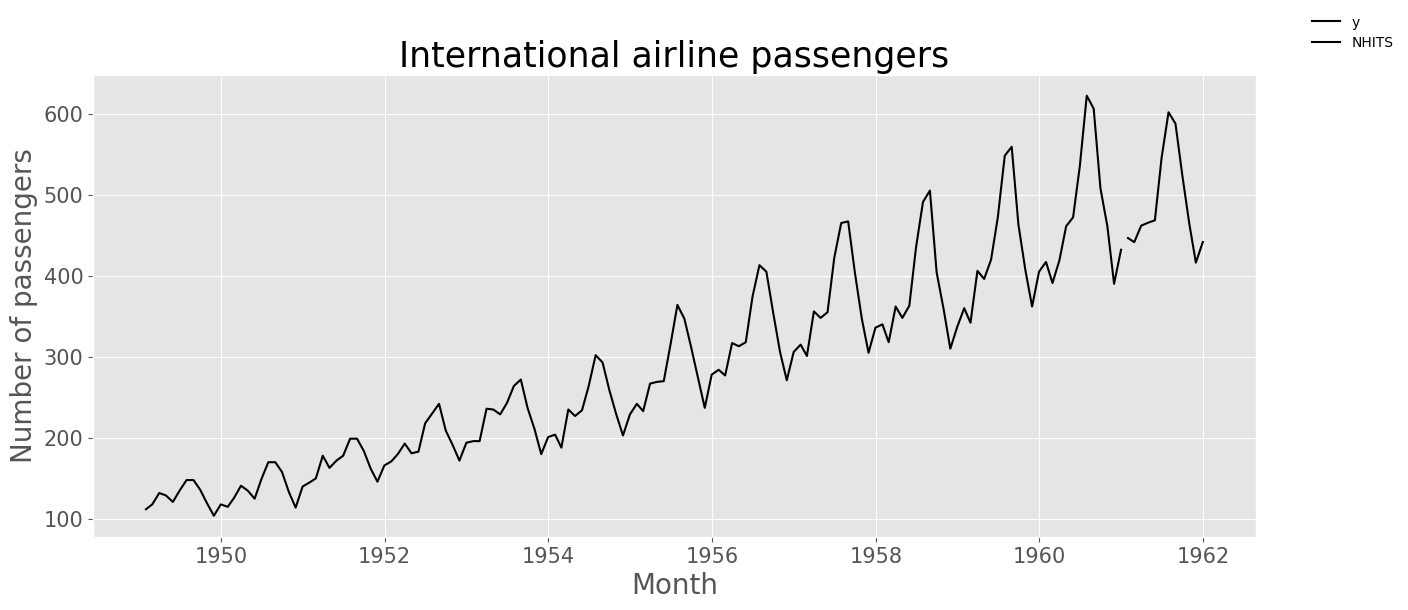

In [5]:
air_passengers_df = AirPassengersDF.copy()
transfer_preds = nf.predict(df=air_passengers_df)


plot_series(air_passengers_df, transfer_preds,
            xlabel="Month", ylabel="Number of passengers",
            title = "International airline passengers",
            rm_legend=False,)

# Probabilistic forecasts with exogenous variables with Moirai
Moirai is an encoder-only transformer model developed by Salesforce. It is a probabilistic model that also relies on patching the input series. It supports both historical and future exogenous variables. A disctinct feature of Moirai is that it uses a mixture distribution, using four different distributions, to output more flexible prediction intervals. Its release also comes with LOTSA, an open archive of time series data with 27B data points.


<img src="https://otexts.com/fpppy/nbs/15-foundation-models_files/figure-html/fig-moirai-output-1.png" width="800"/>

 First, we start by converting the dataset to a GluonTS dataset.



In [6]:
df = pd.read_csv("https://otexts.com/fpppy/data/electricity_short.csv", parse_dates=["ds"])
df.head()

,unique_id,ds,y,Exogenous1,Exogenous2,day_0,day_1,day_2,day_3,day_4,day_5,day_6
0,NP,2018-10-15 00:00:00,2.17,34078.0,1791.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,NP,2018-10-15 01:00:00,4.03,33469.0,1489.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,NP,2018-10-15 02:00:00,4.88,33313.0,1233.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NP,2018-10-15 03:00:00,10.47,33535.0,1035.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NP,2018-10-15 04:00:00,17.51,34267.0,854.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
future_ex_vars_df = pd.read_csv(
    "https://otexts.com/fpppy/data/electricity_future_vars.csv", parse_dates=["ds"]
)
future_ex_vars_df.head()

,unique_id,ds,Exogenous1,Exogenous2,day_0,day_1,day_2,day_3,day_4,day_5,day_6
0,NP,2018-12-24 00:00:00,49119.0,461.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,NP,2018-12-24 01:00:00,48115.0,484.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,NP,2018-12-24 02:00:00,47727.0,497.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NP,2018-12-24 03:00:00,47673.0,509.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NP,2018-12-24 04:00:00,47848.0,510.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
full_df = pd.concat([df, future_ex_vars_df], axis=0)
full_df = full_df.set_index("ds")

ds = PandasDataset.from_long_dataframe(
    full_df,
    target="y",
    item_id="unique_id",
    feat_dynamic_real=[
        "Exogenous1",
        "Exogenous2",
        "day_0",
        "day_1",
        "day_2",
        "day_3",
        "day_4",
        "day_5",
        "day_6",
    ],
)

In [9]:
train, test_template = split(ds, offset=-24)
test_data = test_template.generate_instances(
    prediction_length=24,
    windows=1,
    distance=24,
)

In [10]:
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.0-R-large"),
    prediction_length=24,
    context_length=240,
    patch_size="auto",
    num_samples=50,
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.24G [00:00<?, ?B/s]

In [11]:
predictor = model.create_predictor(batch_size=32)
forecasts = predictor.predict(test_data.input)
forecasts = list(forecasts)

In [12]:
forecasts[0]

gluonts.model.forecast.SampleForecast(info=None, item_id='NP', samples=array([[49.86241 , 51.554813, 51.050453, ..., 52.129948, 57.875576,
        50.125168],
       [51.683624, 57.047325, 49.765343, ..., 54.71743 , 47.48584 ,
        44.066868],
       [50.738674, 49.838673, 46.700104, ..., 49.714172, 55.71243 ,
        46.318146],
       ...,
       [51.381004, 52.292446, 50.73222 , ..., 71.42424 , 54.80716 ,
        50.00875 ],
       [51.508625, 50.693512, 50.507557, ..., 60.483143, 52.028214,
        52.393284],
       [52.02459 , 51.190742, 50.876007, ..., 52.136723, 48.337196,
        50.176888]], dtype=float32), start_date=Period('2018-12-24 00:00', 'H'))

In [13]:
moirai_preds = np.median(forecasts[0].samples, axis=0)

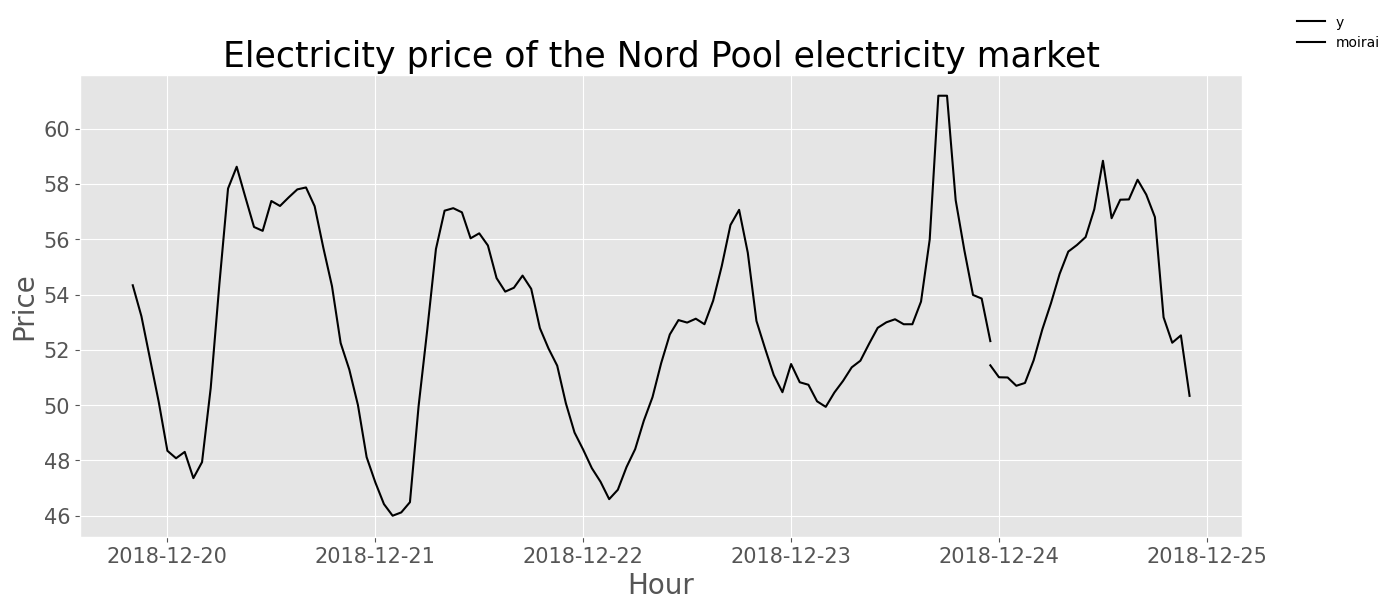

In [22]:
fcst_df = pd.DataFrame({'unique_id':np.tile('NP', 24), 'ds':pd.date_range(df['ds'].iloc[-1], periods=24, freq='1h'), 'moirai':moirai_preds})
plot_series(df, fcst_df, max_insample_length=100,
            xlabel="Hour", ylabel="Price",
            title="Electricity price of the Nord Pool electricity market",
            rm_legend=False)

In [23]:
samples_df = pd.DataFrame(forecasts[0].samples.T,
                          index=pd.date_range(df['ds'].iloc[-1], periods=24, freq='1h'),
                          columns=[f'sample_{i}' for i in range(forecasts[0].samples.shape[0])])

# 2. Join with the existing forecast DataFrame
samples_df = pd.merge(fcst_df, samples_df, left_on='ds', right_index=True, how='left')


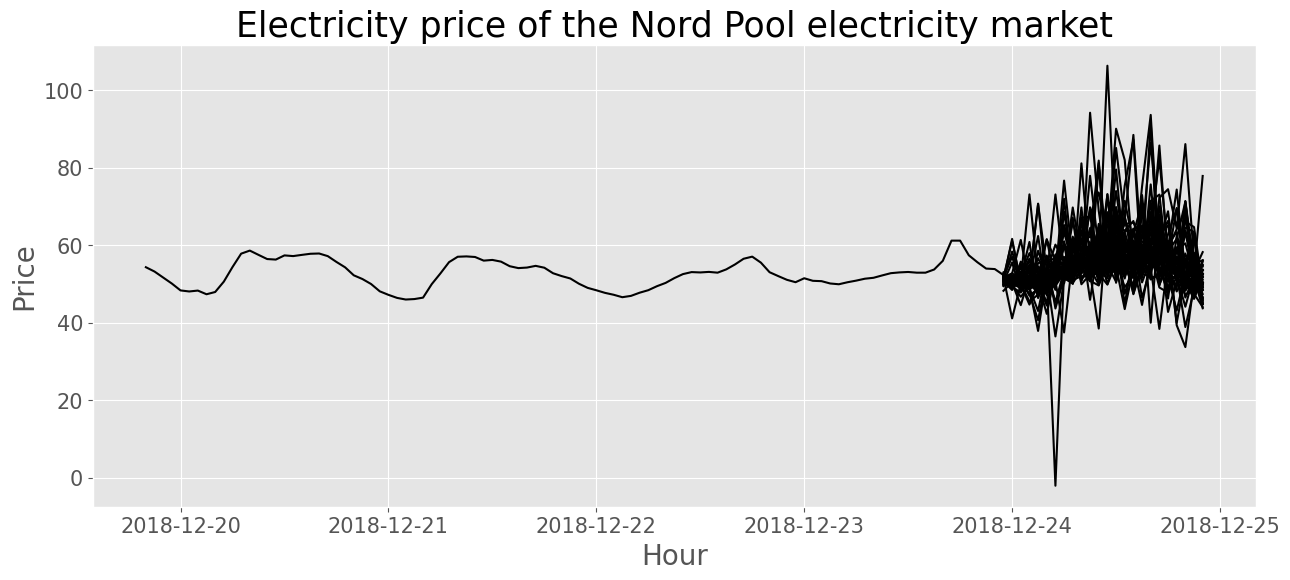

In [30]:
plot_series(df, samples_df, max_insample_length=100,
            xlabel="Hour", ylabel="Price",
            title="Electricity price of the Nord Pool electricity market",
            rm_legend=True)
